# Channel-by-precursor decomposition (emissions-based)

This reads `004_run_magicc_emissions_based.py`/
`005_emissions_based_decomposition.py`'s `fixed_`-prefixed output - i.e. leave-one-out 
runs supplied with historical emissions from 1751 and given the CH4/N2O "hardwired 
history" budget-closure re-anchoring wherever that gas isn't itself switched. 

The "Total channel ERF"/"Total channel GSAT" reference markers come from
`002`'s burden-based output. This notebook is a cross-method comparison by design 
(real chemistry-driven non-additivity between summed precursor marginals and the real 
combined run, not reconciled away). Output files are prefixed `fixed_`.

`005` decomposes each precursor's (NOx/CO/VOC/CH4) own leave-one-out effect into the
forcing channels it acts through (Tropospheric Ozone, CH4, Stratospheric H2O, ...).
This notebook flips that around: for a given *channel* (Tropospheric Ozone,
Stratospheric H2O), how much of its forcing comes from each precursor? All four
precursors already have their own leave-one-out delta for both channels computed in
`004`/`005` - this is a pure reshape-and-replot of already-computed output.

**Expect non-additivity here too** - tropospheric ozone chemistry is nonlinear in 
NOx/VOC/CO/CH4 concentrations (NOx-limited vs. VOC-limited regimes), so the four marginals 
summed won't exactly equal the real `Effective Radiative Forcing|<channel>` total. Reported
explicitly via the same reference-marker pattern `006` uses (Total channel ERF vs. Sum
of attributed precursor contributions).

## Imports

In [1]:
from pathlib import Path

from pandas_openscm.db import FeatherDataBackend, FeatherIndexBackend, OpenSCMDB

import attribution_common as ac

## Configuration

In [2]:
EMBARGOED = True
"""Set True once running against real (embargoed) ScenarioMIP scenarios. Must match
004's/005's own EMBARGOED setting, since this notebook reads their output directly."""
DATA_DIR = Path("../data/embargoed") if EMBARGOED else Path("../data")

BASE_SCENARIOS = ac.load_base_scenarios(DATA_DIR)
"""Auto-discovered from 001's base_scenarios.json manifest."""

SWITCH_YEAR = 1750
"""Must match 004's SWITCH_YEAR - used to reconstruct each precursor's counterfactual
scenario name."""

YEARS_TO_PLOT = [2050, 2100]
BASELINE_YEAR = 2025
REGION = ac.REGION

OUTPUT_PREFIX = "fixed_"
"""Prepended to every plot filename below."""

BURDEN_SCM_OUTPUT_DB_DIR = DATA_DIR / "consistent_burden_scm_output_db"
"""002's own output - source of each channel's own reported ERF total, used as the
"Total channel ERF" reference marker."""

BURDEN_GSAT_DB_DIR = DATA_DIR / "consistent_burden_gsat_db"
"""002's own QEXTRA channel GSAT output - source of each channel's own burden-based
GSAT contribution, used as the GSAT "Total channel" reference marker (the same
quantity 006's GSAT summary plot stacks as its "Tropospheric Ozone" bucket)."""

EMISSIONS_CHANNEL_GSAT_DB_DIR = DATA_DIR / "fixed_emissions_channel_gsat_db"
"""005's `fixed_`-prefixed QEXTRA channel GSAT output, one scenario per (base_scenario,
precursor, channel)."""

PLOTS_DIR = Path("../data/plots")
"""Always plain data/plots/, regardless of EMBARGOED - plots are not considered
sensitive, only raw emissions/MAGICC output."""
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

PRECURSORS = ["CH4", "NOx", "CO", "VOC"]
"""All four already have their own leave-one-out run in 004, and both channels below are
already among the output variables each of their runs requested."""

CHANNELS_TO_DECOMPOSE = {
    "Tropospheric Ozone": "Effective Radiative Forcing|Tropospheric Ozone",
    "Stratospheric H2O": "Effective Radiative Forcing|CH4 Oxidation Stratospheric H2O",
}

BUCKET_COLORS = dict(zip(PRECURSORS, ac.CATEGORICAL_PALETTE))
"""Fixed categorical order (see attribution_common.py's CATEGORICAL_PALETTE) - a new
bucket set from 006's (this notebook decomposes one of 006's buckets further), so not
matched to 006's hand-picked hex codes. Override here the same way 006 does if desired."""

"Fixed categorical order (see attribution_common.py's CATEGORICAL_PALETTE) - a new\nbucket set from 006's (this notebook decomposes one of 006's buckets further), so not\nmatched to 006's hand-picked hex codes. Override here the same way 006 does if desired."

In [3]:
BUCKET_COLORS = {'CH4': 'LightSkyBlue', 'NOx': '#eb6834', 'CO': '#eda100', 'VOC': '#1baf7a'}

## Load each precursor's own leave-one-out output (203's fixed_ per-species dbs)

In [4]:
def emissions_db_dir(species_key):
    """004's `fixed_`-prefixed dirs."""
    return DATA_DIR / f"fixed_emissions_scm_output_db_{ac.slugify(species_key)}"


def counterfactual_scenario_name(base_scenario, species_key):
    return f"{base_scenario}_no_{species_key}_{SWITCH_YEAR}"


precursor_output = {
    species_key: OpenSCMDB(
        backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=emissions_db_dir(species_key)
    ).load(out_columns_type=int)
    for species_key in PRECURSORS
}
for df in precursor_output.values():
    df.columns.name = "year"

burden_scm_output = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=BURDEN_SCM_OUTPUT_DB_DIR
).load(out_columns_type=int)
burden_scm_output.columns.name = "year"


def precursor_delta_series(base_scenario, species_key, variable, year):
    counterfactual = counterfactual_scenario_name(base_scenario, species_key)
    delta = ac.compute_delta(precursor_output[species_key], base_scenario, counterfactual, variable, region=REGION)
    return delta[year]


def total_channel_series(base_scenario, variable, year):
    return ac.member_series(ac.load_erf(burden_scm_output, base_scenario, variable, region=REGION), year)


def driving_scenario_name(base_scenario, species_key):
    """Matches 005's driving_scenario_name = f"{base_scenario}_{species_key}" naming -
    unique per (base_scenario, species_key), avoiding collisions in the QEXTRA output
    scenario names once BASE_SCENARIOS has more than one entry."""
    return f"{base_scenario}_{species_key}"


burden_gsat_by_channel = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=BURDEN_GSAT_DB_DIR
).load(out_columns_type=int)
burden_gsat_by_channel.columns.name = "year"
burden_gsat_by_channel = burden_gsat_by_channel.loc[
    (burden_gsat_by_channel.index.get_level_values("variable") == "Surface Air Temperature Change")
    & (burden_gsat_by_channel.index.get_level_values("region") == REGION)
]

emissions_channel_gsat = OpenSCMDB(
    backend_data=FeatherDataBackend(), backend_index=FeatherIndexBackend(), db_dir=EMISSIONS_CHANNEL_GSAT_DB_DIR
).load(out_columns_type=int)
emissions_channel_gsat.columns.name = "year"
emissions_channel_gsat = emissions_channel_gsat.loc[
    (emissions_channel_gsat.index.get_level_values("variable") == "Surface Air Temperature Change")
    & (emissions_channel_gsat.index.get_level_values("region") == REGION)
]


def precursor_channel_gsat_series(base_scenario, species_key, channel_label, year):
    scenario = f"{driving_scenario_name(base_scenario, species_key)}_forcing_only_{channel_label}"
    mask = emissions_channel_gsat.index.get_level_values("scenario") == scenario
    return ac.member_series(emissions_channel_gsat.loc[mask], year)


def total_channel_gsat_series(base_scenario, channel_label, year):
    """Deliberately NOT rebased to 1850-1900. This value is only ever used as the comparison 
    point for a *sum of un-rebased emissions-based leave-one-out deltas*
    (`precursor_channel_gsat_series` above) - both in the additivity check and in the
    plot's reference marker. Rebasing only this side would inject a spurious,
    non-cancelling offset into that comparison, on top of the real chemistry-driven non-additivity 
    this notebook is investigating."""
    scenario = f"{base_scenario}_forcing_only_{channel_label}"
    mask = burden_gsat_by_channel.index.get_level_values("scenario") == scenario
    return ac.member_series(burden_gsat_by_channel.loc[mask], year)

## Compute per-(scenario, year) precursor contributions and reference markers, per channel

Member-level discipline throughout: sum the precursors' per-member delta series first
(aligned on `run_id`), *then* take the median - never `sum(median(a), median(b), ...)`.

In [5]:
channel_bucket_values = {}
channel_reference_markers_values = {}

for channel_label, variable in CHANNELS_TO_DECOMPOSE.items():
    bucket_values = {p: {} for p in PRECURSORS}
    reference_markers_values = {"Total channel ERF": {}, "Sum of attributed": {}}

    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        for year in YEARS_TO_PLOT:
            precursor_series = {p: precursor_delta_series(base_scenario, p, variable, year) for p in PRECURSORS}
            for p in PRECURSORS:
                bucket_values[p][(short_name, year)] = precursor_series[p].median()

            all_precursors_sum = sum(precursor_series.values())
            reference_markers_values["Sum of attributed"][(short_name, year)] = all_precursors_sum.median()
            reference_markers_values["Total channel ERF"][(short_name, year)] = total_channel_series(
                base_scenario, variable, year
            ).median()

    channel_bucket_values[channel_label] = bucket_values
    channel_reference_markers_values[channel_label] = reference_markers_values

## Additivity spot-check

In [6]:
for channel_label in CHANNELS_TO_DECOMPOSE:
    reference_markers_values = channel_reference_markers_values[channel_label]
    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        for year in YEARS_TO_PLOT:
            attributed = reference_markers_values["Sum of attributed"][(short_name, year)]
            total = reference_markers_values["Total channel ERF"][(short_name, year)]
            print(
                f"{channel_label} {short_name} {year}: sum of attributed={attributed:+.4f} W/m^2, "
                f"total={total:+.4f} W/m^2, residual={attributed - total:+.4f} W/m^2"
            )
    print()

Tropospheric Ozone vl 2050: sum of attributed=+0.1871 W/m^2, total=+0.2122 W/m^2, residual=-0.0251 W/m^2
Tropospheric Ozone vl 2100: sum of attributed=+0.0674 W/m^2, total=+0.0834 W/m^2, residual=-0.0160 W/m^2
Tropospheric Ozone l 2050: sum of attributed=+0.3232 W/m^2, total=+0.3465 W/m^2, residual=-0.0233 W/m^2
Tropospheric Ozone l 2100: sum of attributed=+0.1736 W/m^2, total=+0.1970 W/m^2, residual=-0.0234 W/m^2
Tropospheric Ozone ln 2050: sum of attributed=+0.3163 W/m^2, total=+0.3416 W/m^2, residual=-0.0254 W/m^2
Tropospheric Ozone ln 2100: sum of attributed=+0.1848 W/m^2, total=+0.2117 W/m^2, residual=-0.0269 W/m^2
Tropospheric Ozone m 2050: sum of attributed=+0.3556 W/m^2, total=+0.3806 W/m^2, residual=-0.0250 W/m^2
Tropospheric Ozone m 2100: sum of attributed=+0.3553 W/m^2, total=+0.3958 W/m^2, residual=-0.0405 W/m^2
Tropospheric Ozone ml 2050: sum of attributed=+0.3527 W/m^2, total=+0.3780 W/m^2, residual=-0.0253 W/m^2
Tropospheric Ozone ml 2100: sum of attributed=+0.2188 W/m^2

## Plot: absolute ERF by precursor, per channel

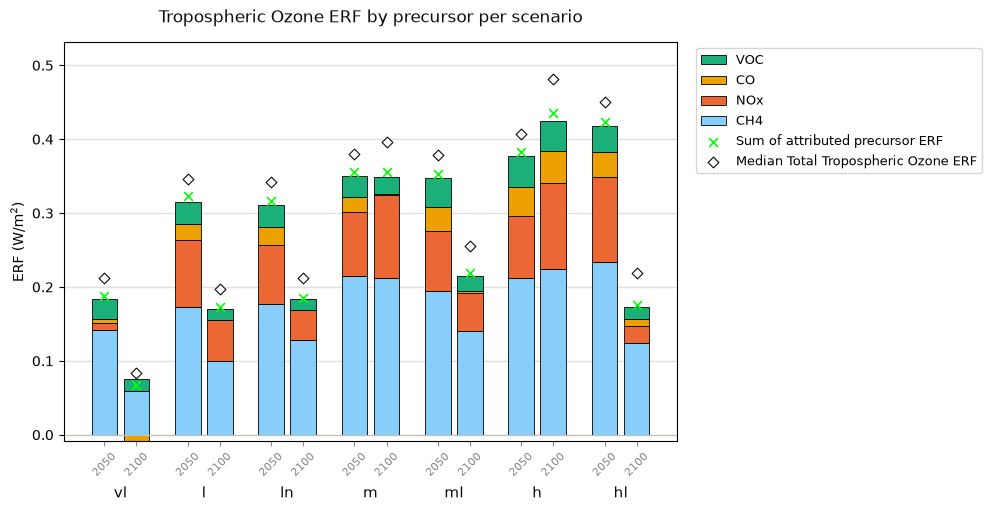

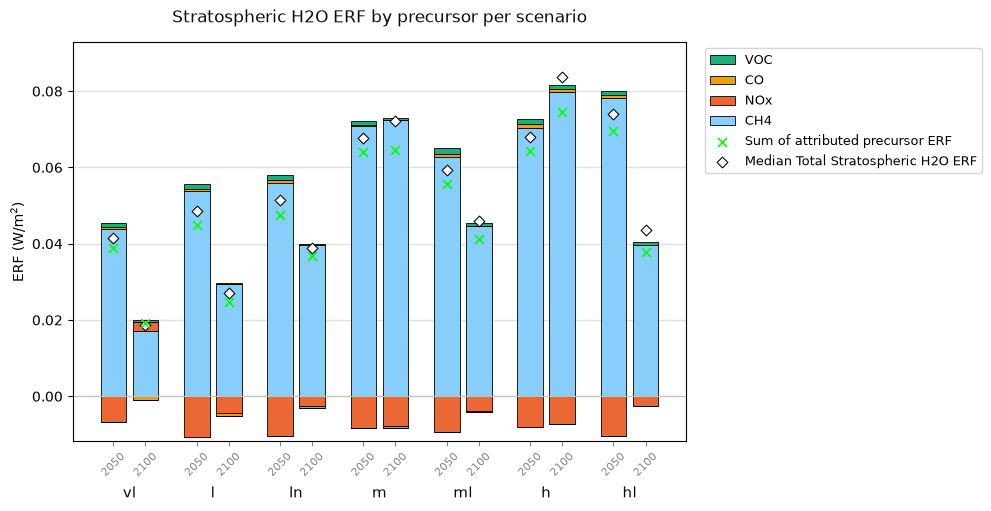

In [7]:
scenario_order = [ac.scenario_short_name(s) for s in BASE_SCENARIOS]

for channel_label, variable in CHANNELS_TO_DECOMPOSE.items():
    reference_markers_values = channel_reference_markers_values[channel_label]
    reference_markers = [
        {
            "label": f"Median Total {channel_label} ERF",
            "values": reference_markers_values["Total channel ERF"],
            "marker": "D",
            "facecolor": ac.COLOR_SURFACE,
            "edgecolor": ac.COLOR_PRIMARY_TEXT,
            "size": 30,
            "linewidths": 0.8,
        },
        {
            "label": "Sum of attributed precursor ERF",
            "values": reference_markers_values["Sum of attributed"],
            "marker": "x",
            "color": "lime",
            "size": 40,
            "linewidths": 1.2,
        },
    ]

    ac.plot_scenario_year_stacked_bars(
        bucket_values=channel_bucket_values[channel_label],
        bucket_colors=BUCKET_COLORS,
        reference_markers=reference_markers,
        scenario_order=scenario_order,
        years=YEARS_TO_PLOT,
        title=f"{channel_label} ERF by precursor per scenario",
        ylabel="ERF (W/m$^2$)",
        out_path=PLOTS_DIR / f"{OUTPUT_PREFIX}emissions_{ac.slugify(channel_label)}_by_precursor_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
    )

## Compute deltas relative to 2025, per channel

In [8]:
channel_bucket_values_delta = {}
channel_reference_markers_values_delta = {}

for channel_label, variable in CHANNELS_TO_DECOMPOSE.items():
    bucket_values_delta = {p: {} for p in PRECURSORS}
    reference_markers_values_delta = {"Total channel ERF": {}, "Sum of attributed": {}}

    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        precursor_series_baseline = {
            p: precursor_delta_series(base_scenario, p, variable, BASELINE_YEAR) for p in PRECURSORS
        }
        total_baseline = total_channel_series(base_scenario, variable, BASELINE_YEAR)

        for year in YEARS_TO_PLOT:
            precursor_series = {p: precursor_delta_series(base_scenario, p, variable, year) for p in PRECURSORS}
            for p in PRECURSORS:
                bucket_values_delta[p][(short_name, year)] = (
                    precursor_series[p] - precursor_series_baseline[p]
                ).median()

            all_precursors_sum = sum(precursor_series.values())
            all_precursors_sum_baseline = sum(precursor_series_baseline.values())
            reference_markers_values_delta["Sum of attributed"][(short_name, year)] = (
                all_precursors_sum - all_precursors_sum_baseline
            ).median()
            reference_markers_values_delta["Total channel ERF"][(short_name, year)] = (
                total_channel_series(base_scenario, variable, year) - total_baseline
            ).median()

    channel_bucket_values_delta[channel_label] = bucket_values_delta
    channel_reference_markers_values_delta[channel_label] = reference_markers_values_delta

## Plot: deltas relative to 2025, per channel

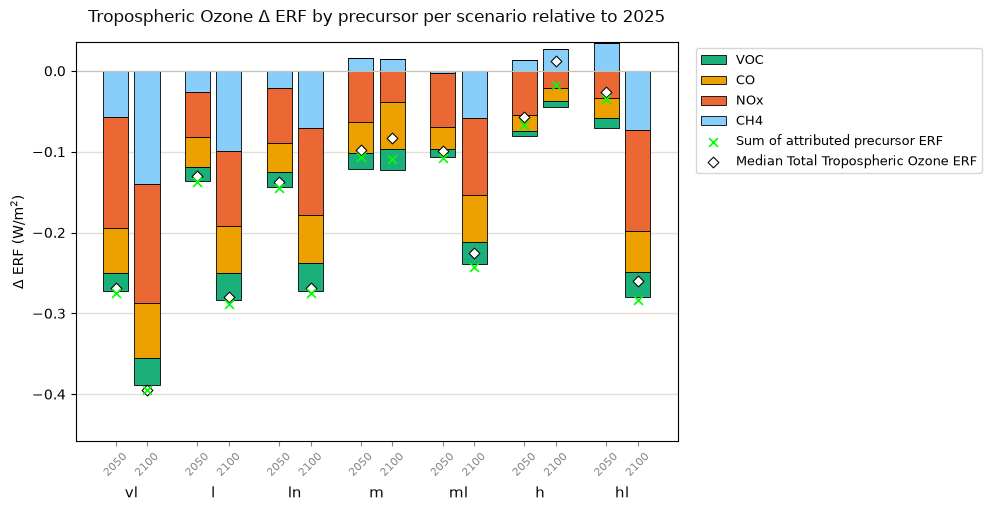

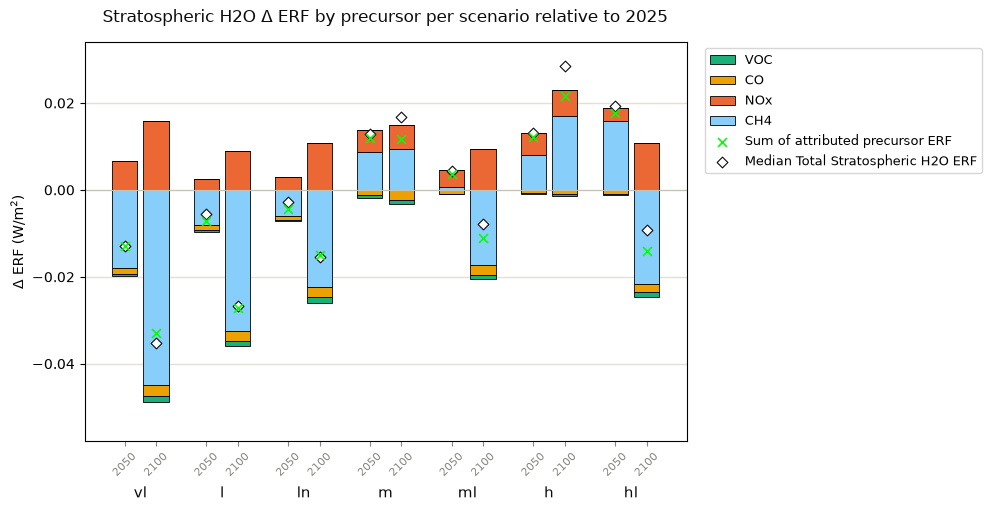

In [9]:
for channel_label, variable in CHANNELS_TO_DECOMPOSE.items():
    reference_markers_values_delta = channel_reference_markers_values_delta[channel_label]
    reference_markers_delta = [
        {
            "label": f"Median Total {channel_label} ERF",
            "values": reference_markers_values_delta["Total channel ERF"],
            "marker": "D",
            "facecolor": ac.COLOR_SURFACE,
            "edgecolor": ac.COLOR_PRIMARY_TEXT,
            "size": 30,
            "linewidths": 0.8,
        },
        {
            "label": "Sum of attributed precursor ERF",
            "values": reference_markers_values_delta["Sum of attributed"],
            "marker": "x",
            "color": "lime",
            "size": 40,
            "linewidths": 1.2,
        },
    ]

    ac.plot_scenario_year_stacked_bars(
        bucket_values=channel_bucket_values_delta[channel_label],
        bucket_colors=BUCKET_COLORS,
        reference_markers=reference_markers_delta,
        scenario_order=scenario_order,
        years=YEARS_TO_PLOT,
        title=rf"{channel_label} $\Delta$ ERF by precursor per scenario relative to 2025",
        ylabel=r"$\Delta$ ERF (W/m$^2$)",
        out_path=PLOTS_DIR
        / f"{OUTPUT_PREFIX}emissions_{ac.slugify(channel_label)}_by_precursor_delta_2025_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
    )

# GSAT versions of the two plots above

Same buckets/markers/layout, but reading each precursor's own GSAT contribution to
the channel (from `005`'s QEXTRA rerun of that precursor's own channel-delta ERF)
instead of the ERF delta itself. The "Total channel GSAT contribution" reference
marker is the *burden-based* (002) QEXTRA channel GSAT for the same channel - the same
quantity 006's GSAT master plot stacks as its own "Tropospheric Ozone"/"Stratospheric
H2O" bucket - not the emissions-based leave-one-out total (that measures a *species'*
total GSAT effect across all its channels, not one channel's GSAT effect across all
its precursors, so it isn't the right comparison here).

## GSAT: compute per-(scenario, year) precursor contributions and reference markers, per channel

In [10]:
channel_bucket_values_gsat = {}
channel_reference_markers_values_gsat = {}

for channel_label in CHANNELS_TO_DECOMPOSE:
    bucket_values_gsat = {p: {} for p in PRECURSORS}
    reference_markers_values_gsat = {"Total channel GSAT": {}, "Sum of attributed": {}}

    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        for year in YEARS_TO_PLOT:
            precursor_series = {
                p: precursor_channel_gsat_series(base_scenario, p, channel_label, year) for p in PRECURSORS
            }
            for p in PRECURSORS:
                bucket_values_gsat[p][(short_name, year)] = precursor_series[p].median()

            all_precursors_sum = sum(precursor_series.values())
            reference_markers_values_gsat["Sum of attributed"][(short_name, year)] = all_precursors_sum.median()
            reference_markers_values_gsat["Total channel GSAT"][(short_name, year)] = total_channel_gsat_series(
                base_scenario, channel_label, year
            ).median()

    channel_bucket_values_gsat[channel_label] = bucket_values_gsat
    channel_reference_markers_values_gsat[channel_label] = reference_markers_values_gsat

## GSAT: additivity spot-check

In [11]:
for channel_label in CHANNELS_TO_DECOMPOSE:
    reference_markers_values_gsat = channel_reference_markers_values_gsat[channel_label]
    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        for year in YEARS_TO_PLOT:
            attributed = reference_markers_values_gsat["Sum of attributed"][(short_name, year)]
            total = reference_markers_values_gsat["Total channel GSAT"][(short_name, year)]
            print(
                f"{channel_label} {short_name} {year}: sum of attributed={attributed:+.4f} K, "
                f"total={total:+.4f} K, residual={attributed - total:+.4f} K"
            )
    print()

Tropospheric Ozone vl 2050: sum of attributed=+0.1480 K, total=+0.1616 K, residual=-0.0136 K
Tropospheric Ozone vl 2100: sum of attributed=+0.0659 K, total=+0.0763 K, residual=-0.0104 K
Tropospheric Ozone l 2050: sum of attributed=+0.1985 K, total=+0.2119 K, residual=-0.0135 K
Tropospheric Ozone l 2100: sum of attributed=+0.1240 K, total=+0.1386 K, residual=-0.0146 K
Tropospheric Ozone ln 2050: sum of attributed=+0.2008 K, total=+0.2146 K, residual=-0.0138 K
Tropospheric Ozone ln 2100: sum of attributed=+0.1270 K, total=+0.1421 K, residual=-0.0151 K
Tropospheric Ozone m 2050: sum of attributed=+0.2043 K, total=+0.2197 K, residual=-0.0154 K
Tropospheric Ozone m 2100: sum of attributed=+0.2059 K, total=+0.2272 K, residual=-0.0213 K
Tropospheric Ozone ml 2050: sum of attributed=+0.2091 K, total=+0.2237 K, residual=-0.0146 K
Tropospheric Ozone ml 2100: sum of attributed=+0.1478 K, total=+0.1674 K, residual=-0.0196 K
Tropospheric Ozone h 2050: sum of attributed=+0.2159 K, total=+0.2324 K, r

## GSAT: plot

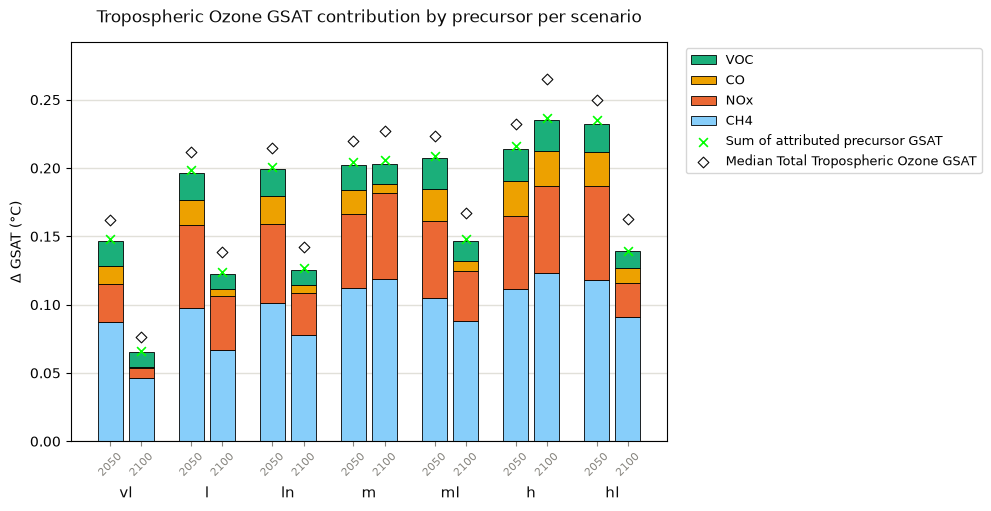

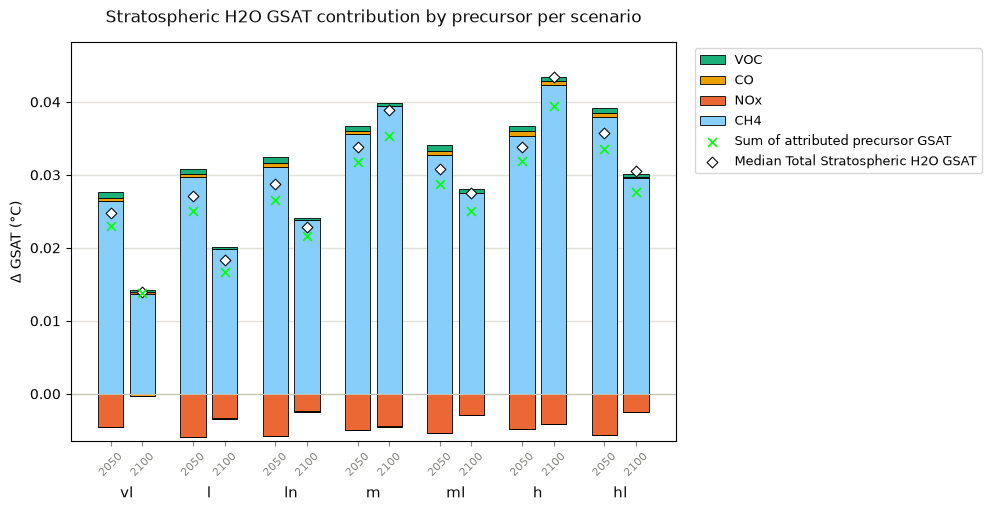

In [12]:
for channel_label in CHANNELS_TO_DECOMPOSE:
    reference_markers_values_gsat = channel_reference_markers_values_gsat[channel_label]
    reference_markers_gsat = [
        {
            "label": f"Median Total {channel_label} GSAT",
            "values": reference_markers_values_gsat["Total channel GSAT"],
            "marker": "D",
            "facecolor": ac.COLOR_SURFACE,
            "edgecolor": ac.COLOR_PRIMARY_TEXT,
            "size": 30,
            "linewidths": 0.8,
        },
        {
            "label": "Sum of attributed precursor GSAT",
            "values": reference_markers_values_gsat["Sum of attributed"],
            "marker": "x",
            "color": "lime",
            "size": 40,
            "linewidths": 1.2,
        },
    ]

    ac.plot_scenario_year_stacked_bars(
        bucket_values=channel_bucket_values_gsat[channel_label],
        bucket_colors=BUCKET_COLORS,
        reference_markers=reference_markers_gsat,
        scenario_order=scenario_order,
        years=YEARS_TO_PLOT,
        title=f"{channel_label} GSAT contribution by precursor per scenario",
        ylabel=r"$\Delta$ GSAT (°C)",
        out_path=PLOTS_DIR
        / f"{OUTPUT_PREFIX}emissions_{ac.slugify(channel_label)}_by_precursor_gsat_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
    )

## GSAT: compute deltas relative to 2025, per channel

In [13]:
channel_bucket_values_gsat_delta = {}
channel_reference_markers_values_gsat_delta = {}

for channel_label in CHANNELS_TO_DECOMPOSE:
    bucket_values_gsat_delta = {p: {} for p in PRECURSORS}
    reference_markers_values_gsat_delta = {"Total channel GSAT": {}, "Sum of attributed": {}}

    for base_scenario in BASE_SCENARIOS:
        short_name = ac.scenario_short_name(base_scenario)
        precursor_series_baseline = {
            p: precursor_channel_gsat_series(base_scenario, p, channel_label, BASELINE_YEAR) for p in PRECURSORS
        }
        total_baseline = total_channel_gsat_series(base_scenario, channel_label, BASELINE_YEAR)

        for year in YEARS_TO_PLOT:
            precursor_series = {
                p: precursor_channel_gsat_series(base_scenario, p, channel_label, year) for p in PRECURSORS
            }
            for p in PRECURSORS:
                bucket_values_gsat_delta[p][(short_name, year)] = (
                    precursor_series[p] - precursor_series_baseline[p]
                ).median()

            all_precursors_sum = sum(precursor_series.values())
            all_precursors_sum_baseline = sum(precursor_series_baseline.values())
            reference_markers_values_gsat_delta["Sum of attributed"][(short_name, year)] = (
                all_precursors_sum - all_precursors_sum_baseline
            ).median()
            reference_markers_values_gsat_delta["Total channel GSAT"][(short_name, year)] = (
                total_channel_gsat_series(base_scenario, channel_label, year) - total_baseline
            ).median()

    channel_bucket_values_gsat_delta[channel_label] = bucket_values_gsat_delta
    channel_reference_markers_values_gsat_delta[channel_label] = reference_markers_values_gsat_delta

## GSAT: plot deltas relative to 2025, per channel

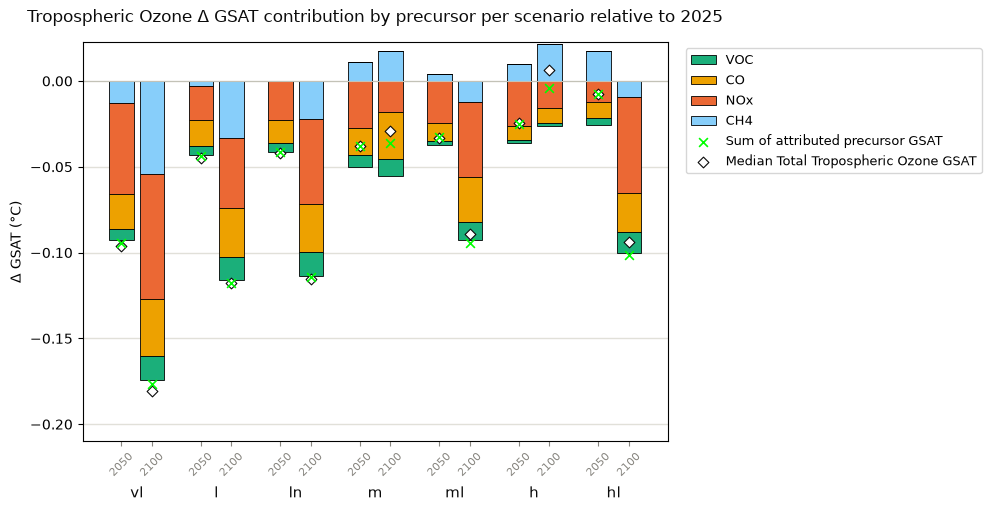

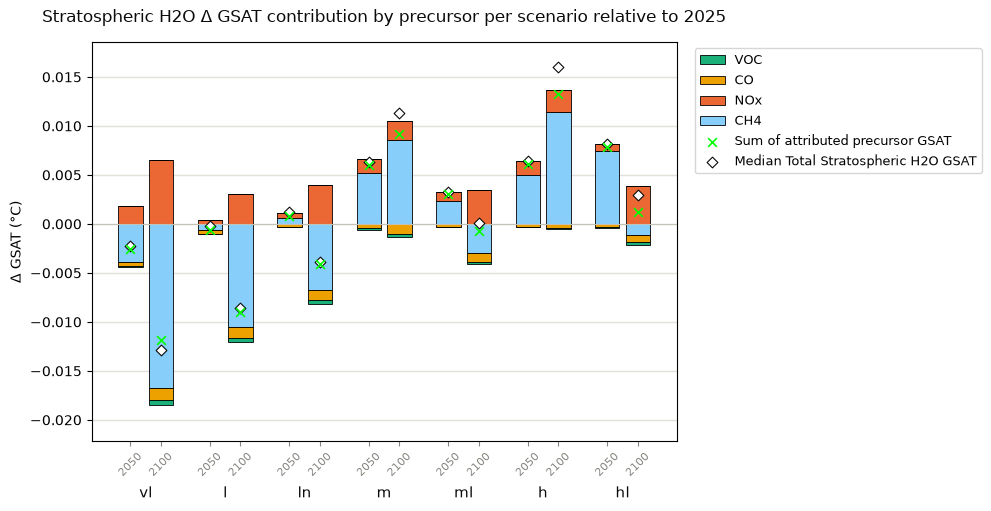

In [14]:
for channel_label in CHANNELS_TO_DECOMPOSE:
    reference_markers_values_gsat_delta = channel_reference_markers_values_gsat_delta[channel_label]
    reference_markers_gsat_delta = [
        {
            "label": f"Median Total {channel_label} GSAT",
            "values": reference_markers_values_gsat_delta["Total channel GSAT"],
            "marker": "D",
            "facecolor": ac.COLOR_SURFACE,
            "edgecolor": ac.COLOR_PRIMARY_TEXT,
            "size": 30,
            "linewidths": 0.8,
        },
        {
            "label": "Sum of attributed precursor GSAT",
            "values": reference_markers_values_gsat_delta["Sum of attributed"],
            "marker": "x",
            "color": "lime",
            "size": 40,
            "linewidths": 1.2,
        },
    ]

    ac.plot_scenario_year_stacked_bars(
        bucket_values=channel_bucket_values_gsat_delta[channel_label],
        bucket_colors=BUCKET_COLORS,
        reference_markers=reference_markers_gsat_delta,
        scenario_order=scenario_order,
        years=YEARS_TO_PLOT,
        title=rf"{channel_label} $\Delta$ GSAT contribution by precursor per scenario relative to 2025",
        ylabel=r"$\Delta$ GSAT (°C)",
        out_path=PLOTS_DIR
        / f"{OUTPUT_PREFIX}emissions_{ac.slugify(channel_label)}_by_precursor_gsat_delta_2025_{'_'.join(str(y) for y in YEARS_TO_PLOT)}.png",
    )